In [1]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

In [2]:
(x_train, _), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = x_train[..., None]
x_test = x_test[..., None]

In [3]:
class Encoder(Model):
    def __init__(self, latent):
        super().__init__()
        self.f = layers.Flatten()
        self.d1 = layers.Dense(256, activation='relu')
        self.d2 = layers.Dense(128, activation='relu')
        self.mu = layers.Dense(latent)
        self.logvar = layers.Dense(latent)
    def call(self, x):
        h = self.d2(self.d1(self.f(x)))
        mu = self.mu(h)
        lv = self.logvar(h)
        eps = tf.random.normal(tf.shape(mu))
        z = mu + tf.exp(0.5 * lv) * eps
        return z, mu, lv

In [4]:
class Decoder(Model):
    def __init__(self, latent):
        super().__init__()
        self.net = tf.keras.Sequential([
            layers.Input((latent,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(256, activation='relu'),
            layers.Dense(784, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])
    def call(self, z): return self.net(z)

In [5]:
class VAE(Model):
    def __init__(self, latent):
        super().__init__()
        self.encoder = Encoder(latent)
        self.decoder = Decoder(latent)
        self.rt = tf.keras.metrics.Mean()
        self.kt = tf.keras.metrics.Mean()
        self.et = tf.keras.metrics.Mean()
    @property
    def metrics(self): return [self.rt, self.kt, self.et]
    def train_step(self, x):
        with tf.GradientTape() as tape:
            z, mu, lv = self.encoder(x)
            xr = self.decoder(z)
            rec = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(x, xr), axis=(1, 2)))
            kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + lv - tf.square(mu) - tf.exp(lv), axis=1))
            loss = rec + kl
        g = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(g, self.trainable_weights))
        self.rt.update_state(rec); self.kt.update_state(kl); self.et.update_state(loss)
        return {"reconstruction": self.rt.result(), "kl": self.kt.result(), "elbo": self.et.result()}


Latent dimension: 2
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - elbo: 300.1277 - kl: 6.6394 - reconstruction: 293.4882
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 273.5721 - kl: 5.9895 - reconstruction: 267.5826
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 269.2853 - kl: 6.0530 - reconstruction: 263.2323
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 266.8402 - kl: 6.0806 - reconstruction: 260.7598
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 265.3827 - kl: 6.0956 - reconstruction: 259.2871
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 264.2792 - kl: 6.1218 - reconstruction: 258.1573
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 263.4794 - kl: 6.1462 - reconstruction: 257.3332
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 262.7721 - kl: 6.1521 - reconstruction: 256.6200
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 262.2026 - kl: 6.1849 - reconstruction: 256.017

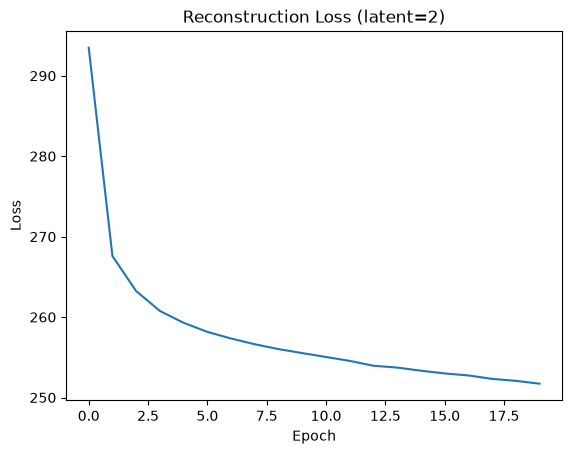

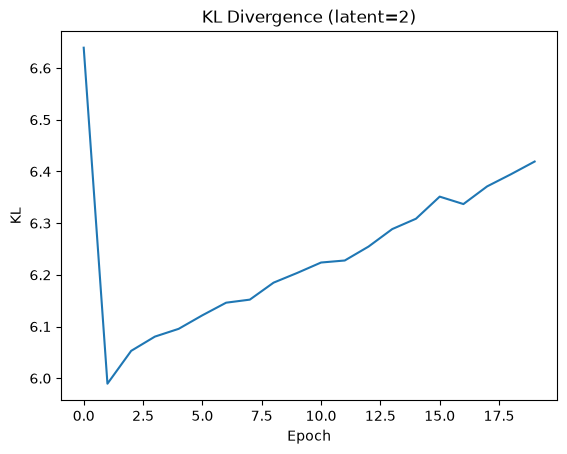

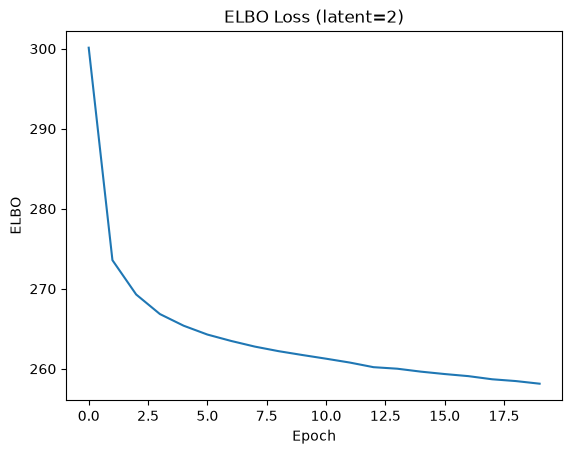

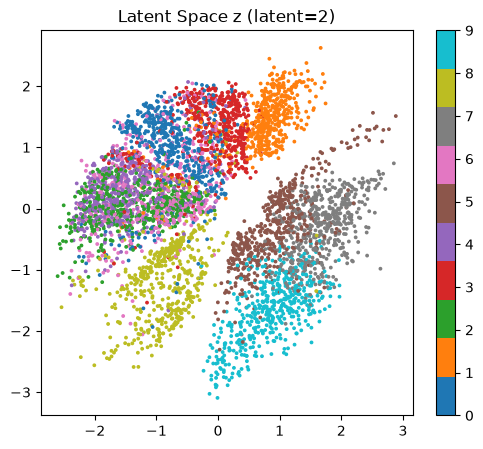

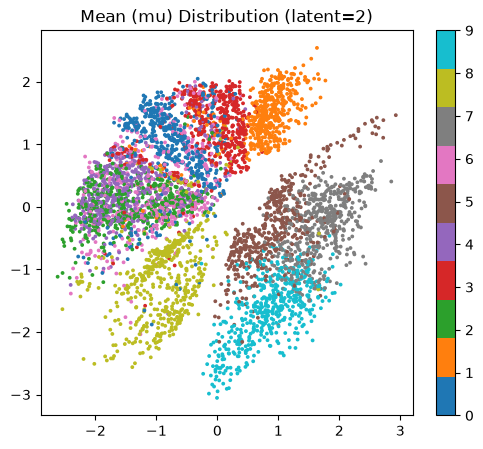

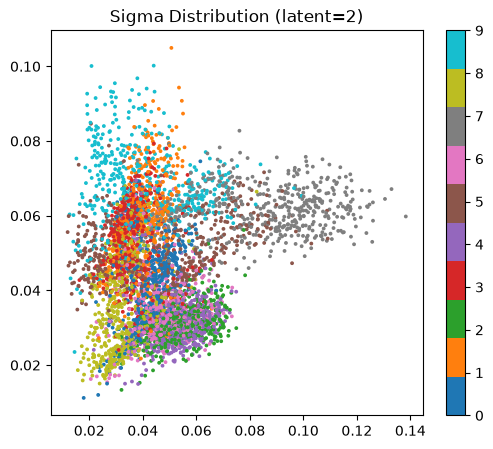

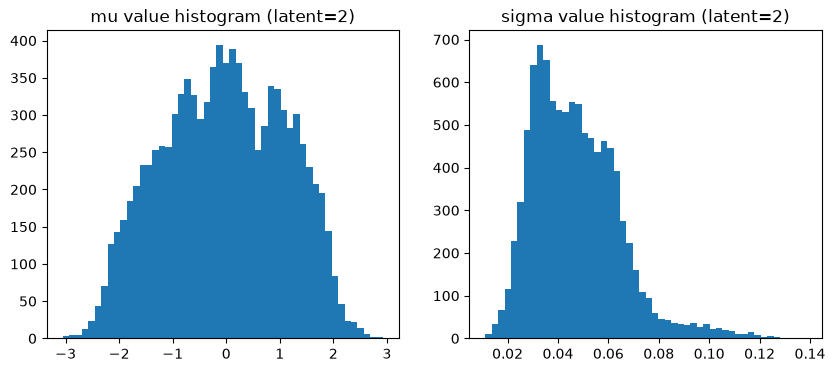

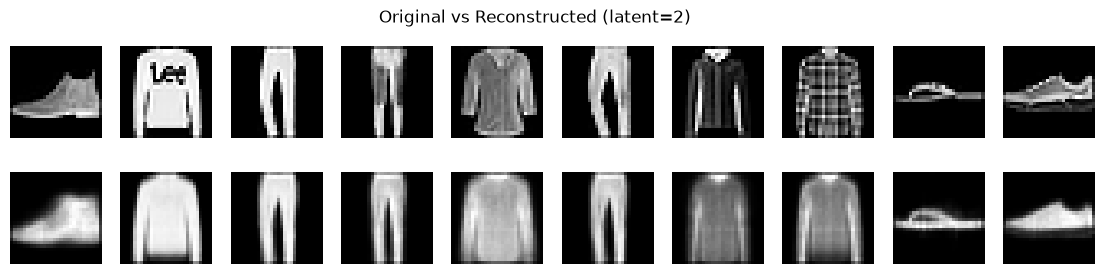

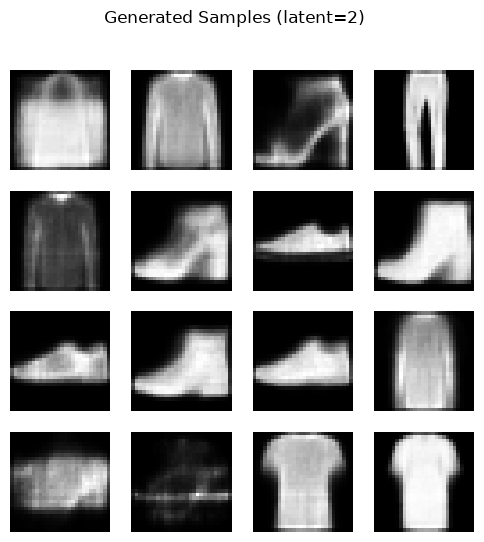

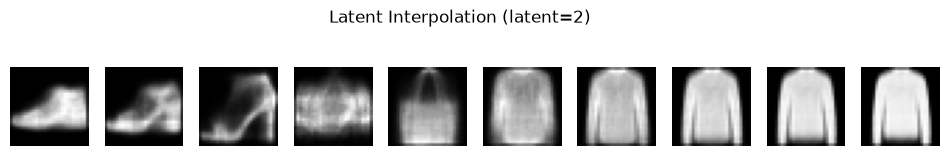


Latent dimension: 4
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - elbo: 289.6135 - kl: 9.0806 - reconstruction: 280.5331
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 256.7795 - kl: 9.4323 - reconstruction: 247.3473
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 252.6216 - kl: 9.3589 - reconstruction: 243.2625
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 250.5982 - kl: 9.3998 - reconstruction: 241.1984
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 249.2523 - kl: 9.4473 - reconstruction: 239.8049
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 248.2428 - kl: 9.4840 - reconstruction: 238.7588
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 247.4992 - kl: 9.4915 - reconstruction: 238.0076
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 246.8862 - kl: 9.5143 - reconstruction: 237.3718
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 246.3918 - kl: 9.5428 - reconstruction: 236.849

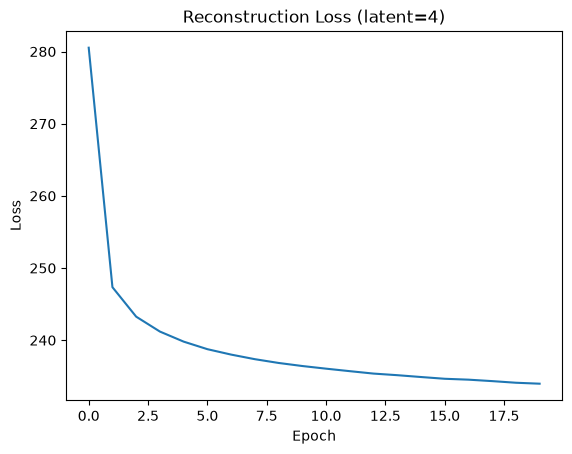

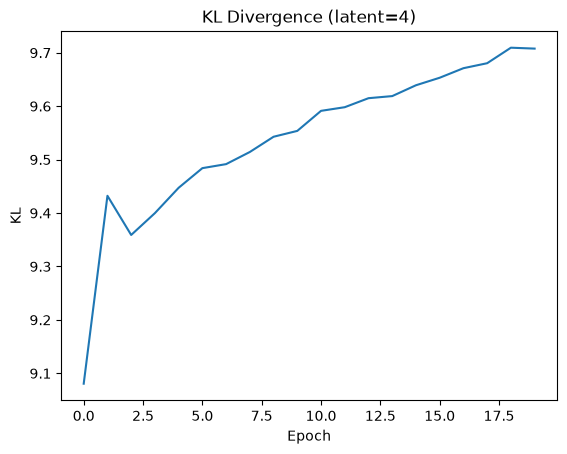

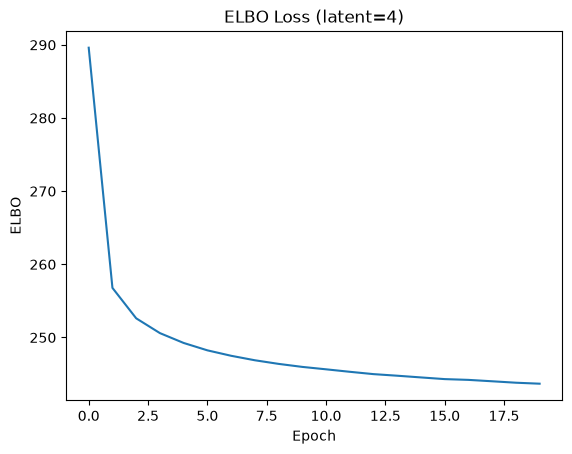

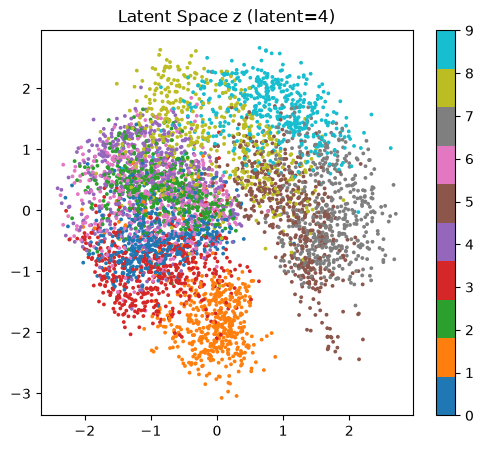

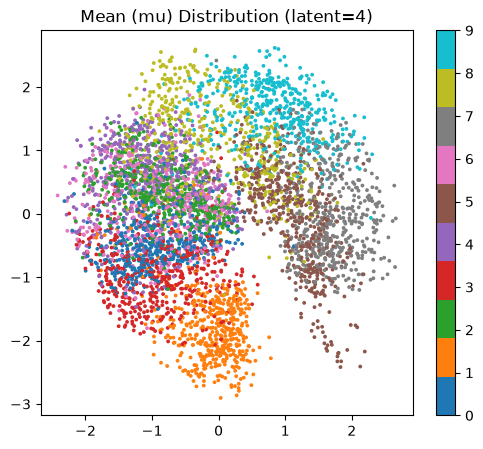

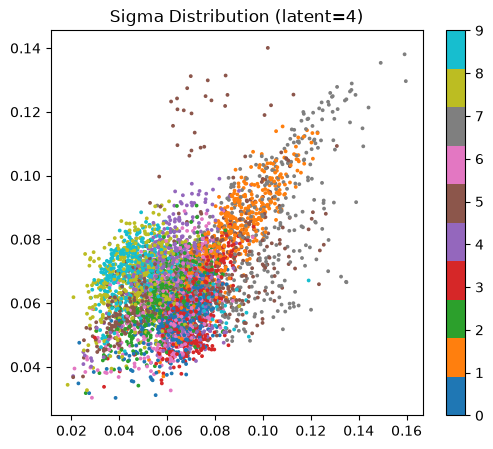

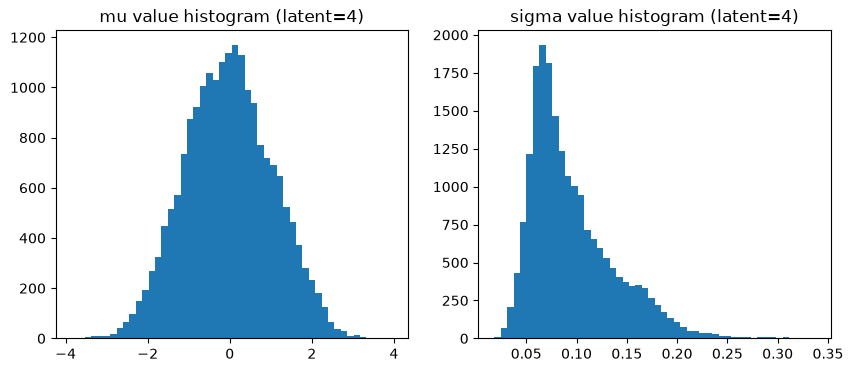

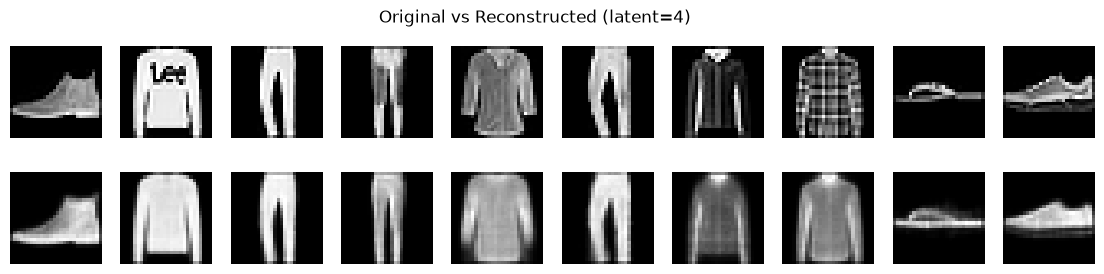

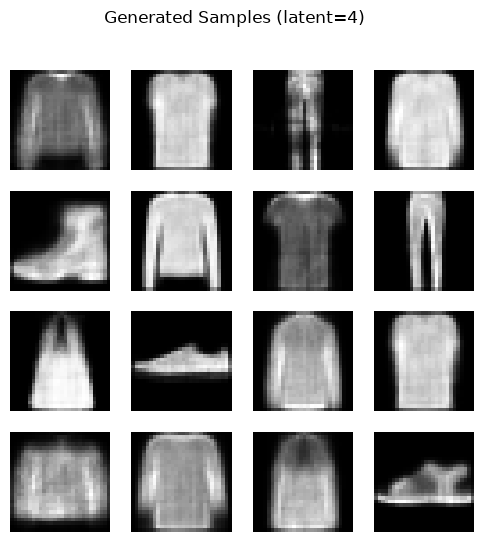

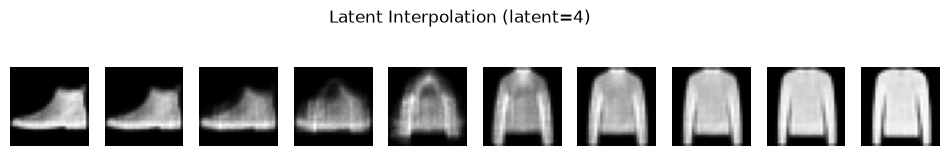


Latent dimension: 6
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - elbo: 286.6743 - kl: 9.7204 - reconstruction: 276.9541
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 254.3302 - kl: 10.8824 - reconstruction: 243.4477
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 249.9853 - kl: 11.2301 - reconstruction: 238.7552
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 247.9193 - kl: 11.3657 - reconstruction: 236.5535
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 246.3974 - kl: 11.4651 - reconstruction: 234.9323
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 245.2609 - kl: 11.5667 - reconstruction: 233.6943
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 244.4372 - kl: 11.6265 - reconstruction: 232.8107
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 243.6804 - kl: 11.7017 - reconstruction: 231.9788
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 243.0998 - kl: 11.7533 - reconstruction:

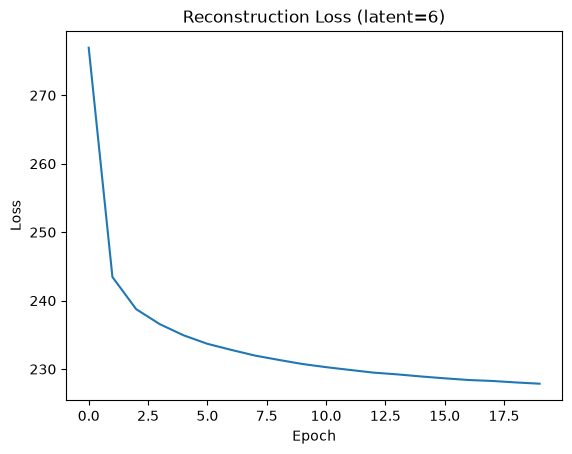

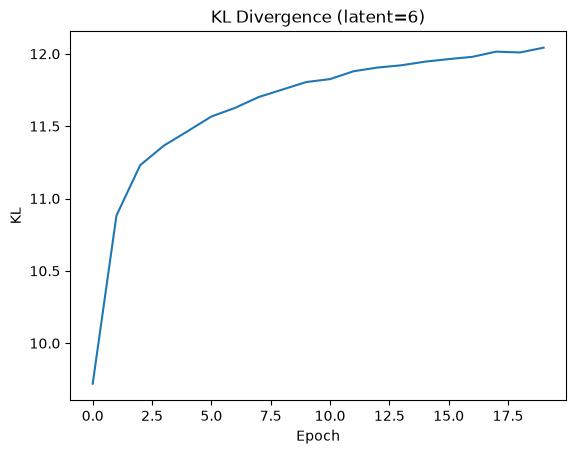

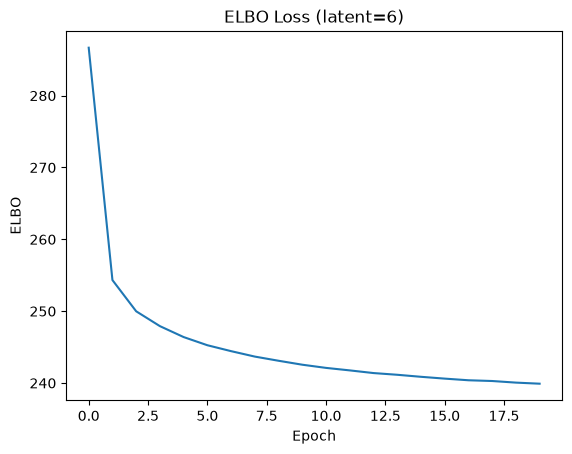

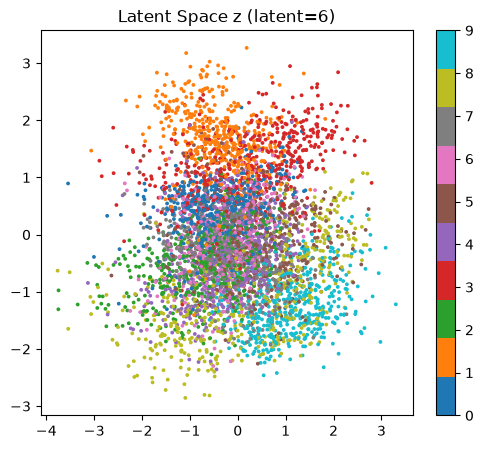

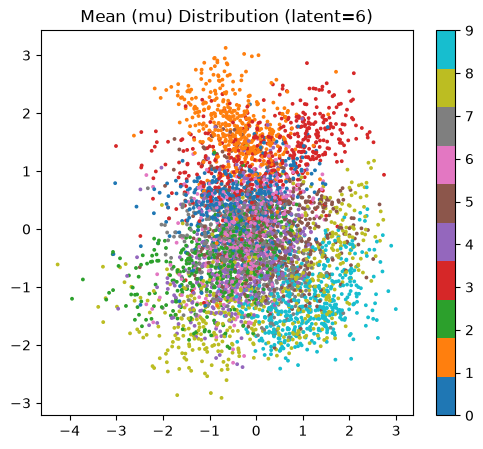

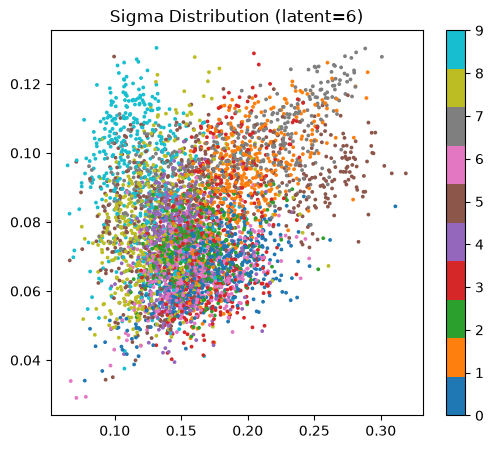

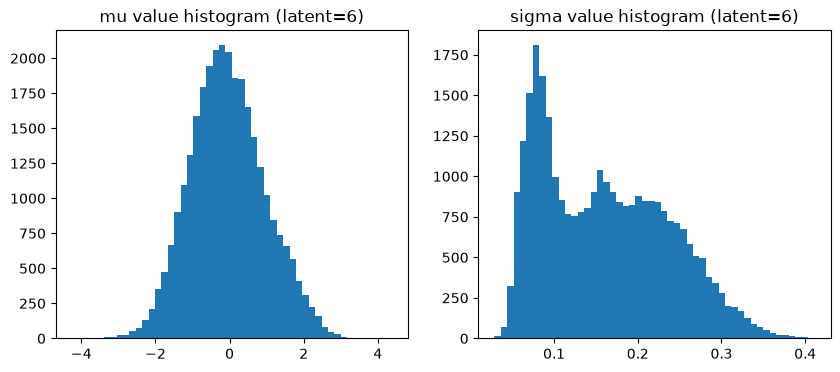

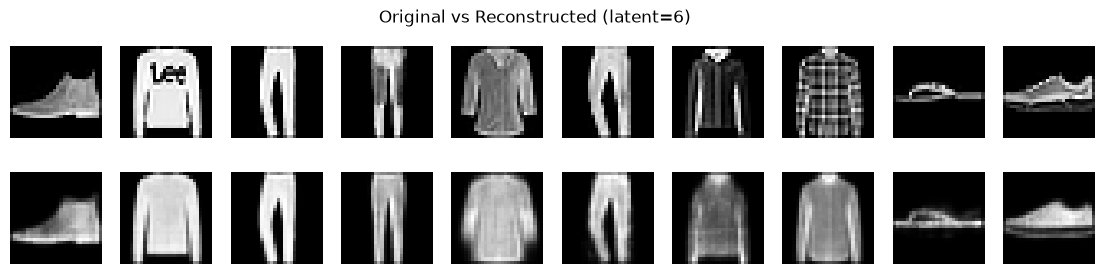

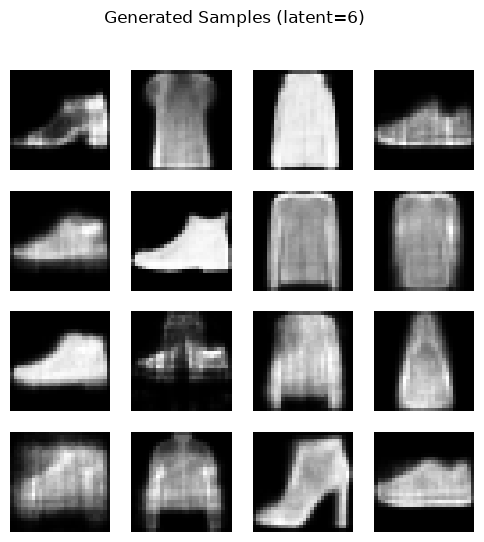

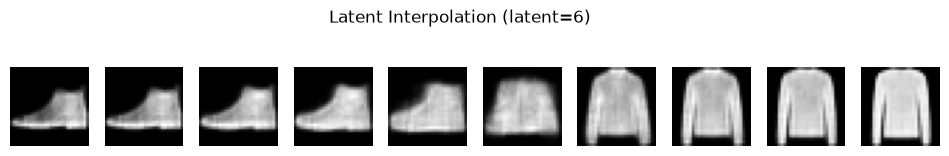


Latent dimension: 8
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - elbo: 287.6877 - kl: 10.4494 - reconstruction: 277.2383
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 254.7276 - kl: 11.4591 - reconstruction: 243.2686
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 250.0220 - kl: 11.7535 - reconstruction: 238.2684
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 247.4798 - kl: 12.0485 - reconstruction: 235.4312
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 245.8406 - kl: 12.2280 - reconstruction: 233.6126
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 244.6903 - kl: 12.3592 - reconstruction: 232.3310
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 243.6815 - kl: 12.4358 - reconstruction: 231.2457
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 243.0034 - kl: 12.4936 - reconstruction: 230.5099
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 242.4546 - kl: 12.5548 - reconstruction

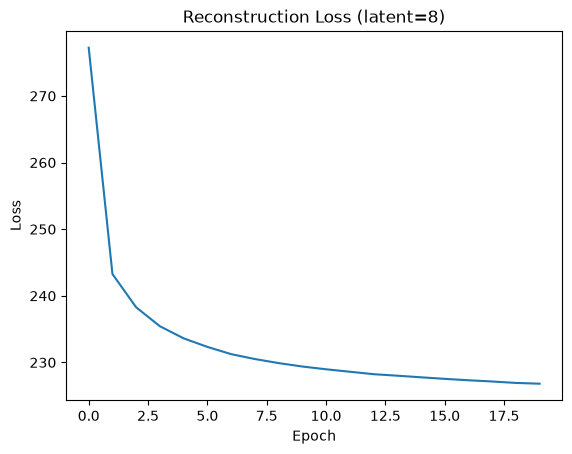

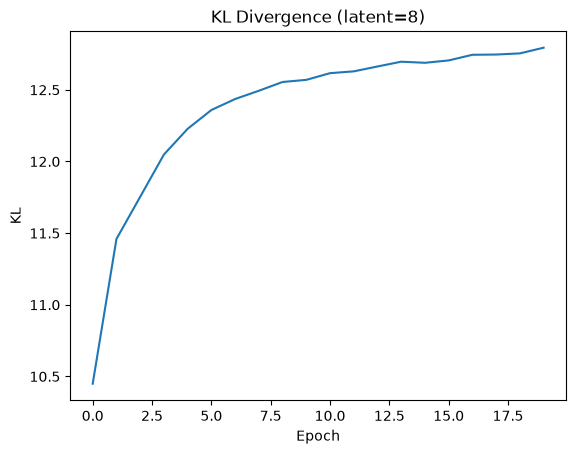

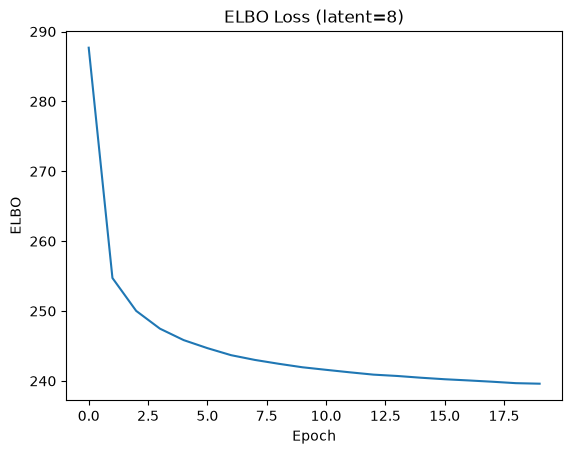

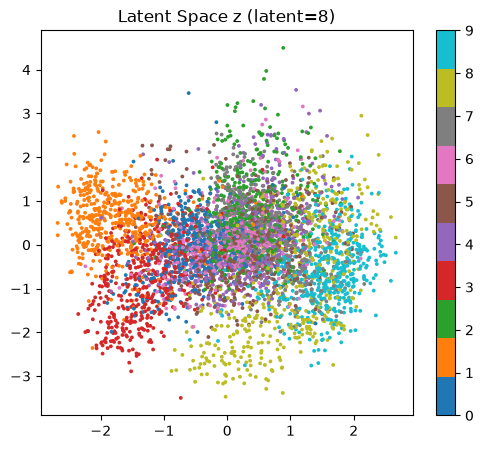

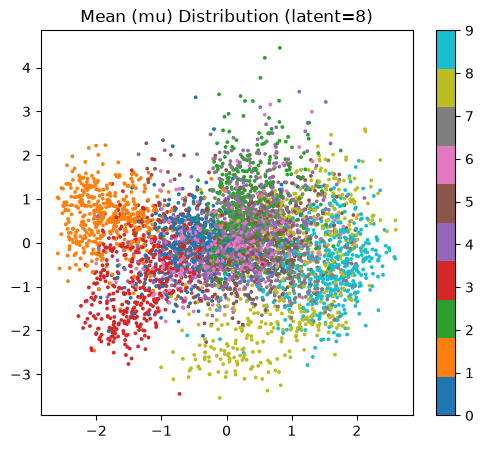

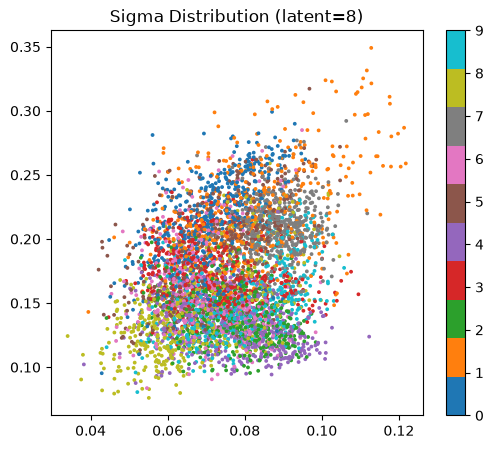

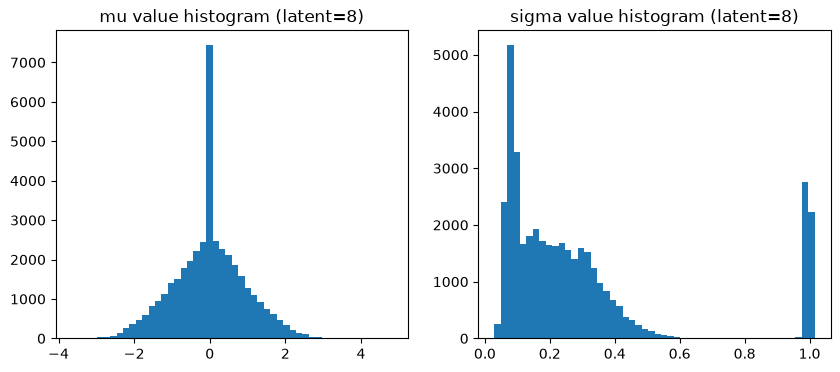

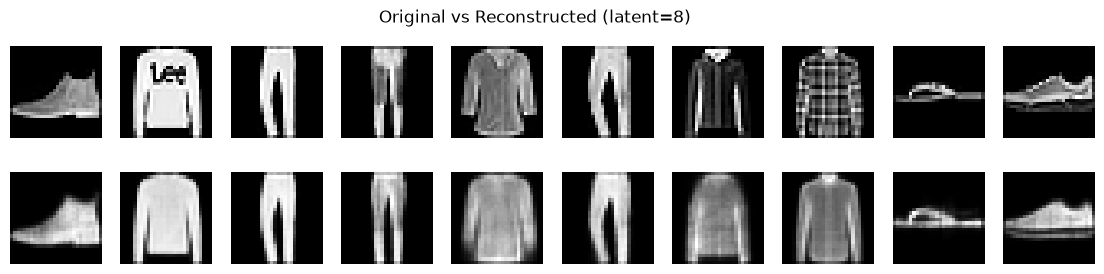

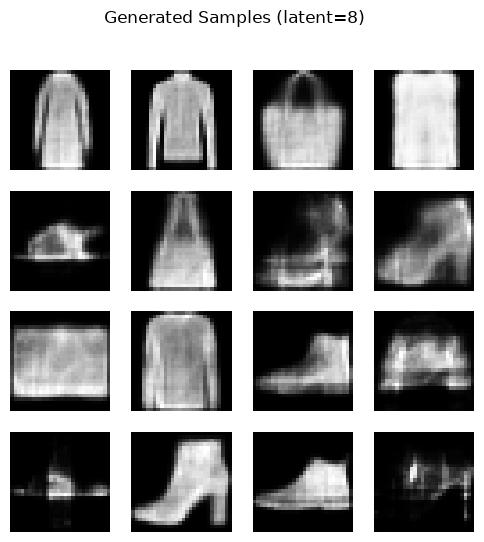

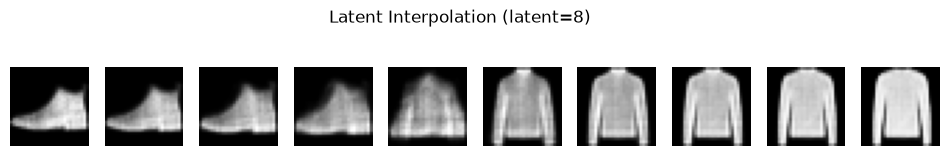

In [6]:
results = {}
models = {}

for latent in [2, 4, 6, 8]:
    print("\nLatent dimension:", latent)
    vae = VAE(latent)
    vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
    h = vae.fit(x_train, epochs=20, batch_size=128, verbose=1)
    models[latent] = vae

    enc_params = vae.encoder.count_params()
    dec_params = vae.decoder.count_params()
    total_params = enc_params + dec_params
    compression = 784 / latent
    print("Encoder params:", enc_params, "Decoder params:", dec_params,
          "Total:", total_params, "Compression ratio:", compression)

    results[latent] = {
        "history": h.history,
        "enc_params": enc_params,
        "dec_params": dec_params,
        "total_params": total_params,
        "compression": compression
    }

    plt.figure(); plt.plot(h.history['reconstruction']); plt.title(f"Reconstruction Loss (latent={latent})")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()

    plt.figure(); plt.plot(h.history['kl']); plt.title(f"KL Divergence (latent={latent})")
    plt.xlabel("Epoch"); plt.ylabel("KL"); plt.show()

    plt.figure(); plt.plot(h.history['elbo']); plt.title(f"ELBO Loss (latent={latent})")
    plt.xlabel("Epoch"); plt.ylabel("ELBO"); plt.show()

    z, mu, lv = vae.encoder.predict(x_test[:5000], verbose=0)
    sigma = np.exp(0.5 * lv)

    plt.figure(figsize=(6, 5))
    plt.scatter(z[:, 0], z[:, 1], c=y_test[:5000], s=3, cmap='tab10')
    plt.colorbar(); plt.title(f"Latent Space z (latent={latent})")
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(mu[:, 0], mu[:, 1], c=y_test[:5000], s=3, cmap='tab10')
    plt.colorbar(); plt.title(f"Mean (mu) Distribution (latent={latent})")
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(sigma[:, 0], sigma[:, 1], c=y_test[:5000], s=3, cmap='tab10')
    plt.colorbar(); plt.title(f"Sigma Distribution (latent={latent})")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(mu.flatten(), bins=50)
    plt.title(f"mu value histogram (latent={latent})")
    plt.subplot(1, 2, 2)
    plt.hist(sigma.flatten(), bins=50)
    plt.title(f"sigma value histogram (latent={latent})")
    plt.show()

    r = vae.decoder(z[:10]).numpy()
    fig, ax = plt.subplots(2, 10, figsize=(14, 3))
    fig.suptitle(f"Original vs Reconstructed (latent={latent})")
    for i in range(10):
        ax[0, i].imshow(x_test[i].squeeze(), cmap='gray'); ax[0, i].axis('off')
        ax[1, i].imshow(r[i].squeeze(), cmap='gray'); ax[1, i].axis('off')
    plt.show()

    samp = vae.decoder(tf.random.normal((16, latent)))
    plt.figure(figsize=(6, 6))
    plt.suptitle(f"Generated Samples (latent={latent})")
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(samp[i].numpy().squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()

    a, b = z[0], z[1]
    plt.figure(figsize=(12, 2))
    plt.suptitle(f"Latent Interpolation (latent={latent})")
    for i, t in enumerate(np.linspace(0, 1, 10)):
        img = vae.decoder(tf.expand_dims((1 - t) * a + t * b, 0))[0]
        plt.subplot(1, 10, i + 1)
        plt.imshow(tf.squeeze(img), cmap='gray')
        plt.axis('off')
    plt.show()

Latent | Enc Params | Dec Params | Total Params | Compression | Final Rec | Final KL | Final ELBO
2 234372 234896 469268 392.0 251.71734619140625 6.419195175170898 258.1365051269531
4 234888 235152 470040 196.0 233.97486877441406 9.707767486572266 243.68275451660156
6 235404 235408 470812 130.66666666666666 227.86544799804688 12.042263984680176 239.90773010253906
8 235920 235664 471584 98.0 226.8066864013672 12.794052124023438 239.60079956054688


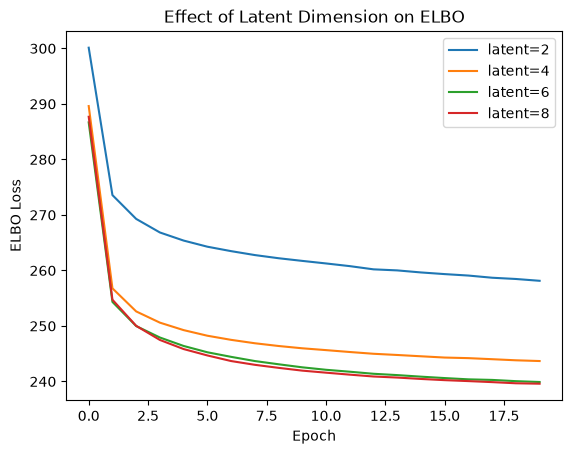

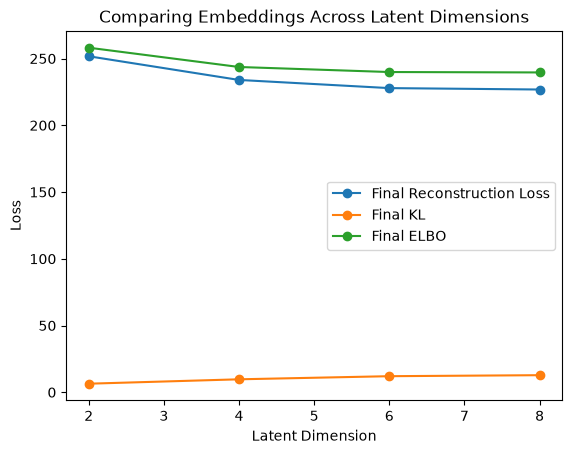

In [7]:
print("Latent | Enc Params | Dec Params | Total Params | Compression | Final Rec | Final KL | Final ELBO")
for latent, r in results.items():
    print(latent, r["enc_params"], r["dec_params"], r["total_params"], r["compression"],
          r["history"]["reconstruction"][-1], r["history"]["kl"][-1], r["history"]["elbo"][-1])

plt.figure()
for latent, r in results.items():
    plt.plot(r["history"]["elbo"], label=f"latent={latent}")
plt.xlabel("Epoch"); plt.ylabel("ELBO Loss")
plt.title("Effect of Latent Dimension on ELBO")
plt.legend(); plt.show()

plt.figure()
plt.plot(list(results.keys()), [r["history"]["reconstruction"][-1] for r in results.values()], marker='o', label="Final Reconstruction Loss")
plt.plot(list(results.keys()), [r["history"]["kl"][-1] for r in results.values()], marker='o', label="Final KL")
plt.plot(list(results.keys()), [r["history"]["elbo"][-1] for r in results.values()], marker='o', label="Final ELBO")
plt.xlabel("Latent Dimension"); plt.ylabel("Loss")
plt.title("Comparing Embeddings Across Latent Dimensions")
plt.legend(); plt.show()